# Predição do diagnóstico de Hipertiroidismo

### Descrição do projeto

A finalidade deste projeto é a criação de um modelo de predição do diagnóstico de Hipertiroidismo. Por se tratar de um modelopreditor de um diagnóstico médico, o foco deve ser minimizar o erro na indentificação dos pacientes com hipertiroidismo. Em outras palavras, o objetivo é minimizar o número de falsos negativos, os casos em que o modelo prevê que o pacciente não tem a doença, mas na verdade ele tem. A situação contrária, de falsos positivos, não é tão grave por que um alarme falso gera menos consequências do que deixar passar um quasro de doença. 

Ele será executado em quatro etapas:
1. Pré-processamento dos dados.
1. Análise exploratória.
1. Treinamento e Otimização dos Modelos.
1. Conclusões.

Na primeira etapa, Pré-processamento dos dados, serão aplicadas as correções à base de dados, bem como as justificativas que motivaram a escolha de cada técnica e metodologia. A seguir, na etapa de análise exploratória, a correalção entre as variáveis e seu balanceamento, além de outras características da base, serão exploradas. A partir dela, novos tratamentos podem ser aplicados ao banco de dados. Na terceira etapa, treinamento e otimização dos modelos, serão discutidos as opções de modelo que melhor se adequam aos objetivos do projeto, os modelos serão então criados, treinados e otimizados. Por fim, o desempenho dos modelos e demais resultados serão apresentados, discutidos e a escolha final será apresentada. 

Apesar dessa separação em etapas, há muitas intersecções entre elas, como, por exemplo, a normalização e balanceamento dos dados, que, por motivos estratégicos, é feita na etapa de treinamento de modelos. A divisão em etapas tem como objetivo guiar o desenvolvimento do projeto, mas sua sequência não é obrigatória em qualquer projeto de _machine learning_.

### Configuração de bibliotecas e dados

In [1]:
# Bibliotecas para operações com dados
import pandas as pd
import random
import re
import numpy as np
pd.set_option('future.no_silent_downcasting', True)

# Biliotecas para gráficos
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

# Bibliotecas para machine learning
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import recall_score, accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score, precision_score
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold # crossvalidation
from sklearn.metrics import confusion_matrix
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

In [2]:
data = pd.read_csv('dados.csv')

## Exploração e Preparação dos dados

Abaixo está um resumo dos dados do projeto. 

São 30 variáveis, em um data frame com 3772 linhas, sem valores nulos. Todas as variáveis são do tipo objeto, mesmo as numéricas. Numa avaliação preliminar do conteúdo dos dados, percebe-se alguns dados faltantes marcados com  '?'.
Assim, as primeiras ações no banco de dados serão:
- Corrigir valores faltantes ("?").
- Corrigir os tipos de dados.
    - Transformar categorias quantitativas em variáveis numéricas.
    - Transformar categorias binárias em númericas (0/1).
    - Transformar categorias categóricas em classes numéricas. 

In [3]:
print("Vizualização inicial dos dados:\n")
data.head()

Vizualização inicial dos dados:



,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


In [4]:
print("Informações gerais da base:\n")
print(data.info())

Informações gerais da base:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 no

In [5]:
print(f'Tamanho total do dataframe: {len(data)}')

Tamanho total do dataframe: 3772


In [6]:
temp = data.isnull().sum()
if temp.sum() ==0: print('Nenhum valor nulo na base.')
else:
     for i,n in enumerate(temp):
          if n > 0: print(f"{i} tem {n} nulos")


Nenhum valor nulo na base.


In [7]:
for i in data.columns:
    print(f'Valores presentes em {i}:\n{data[i].unique()}\n')

Valores presentes em age:
['41' '23' '46' '70' '18' '59' '80' '66' '68' '84' '67' '71' '28' '65'
 '42' '63' '51' '81' '54' '55' '60' '25' '73' '34' '78' '37' '85' '26'
 '58' '64' '44' '48' '61' '35' '83' '21' '87' '53' '77' '27' '69' '74'
 '38' '76' '45' '36' '22' '43' '72' '82' '31' '39' '49' '62' '57' '1' '50'
 '30' '29' '75' '19' '7' '79' '17' '24' '15' '32' '47' '16' '52' '33' '13'
 '10' '89' '56' '20' '90' '40' '88' '14' '86' '94' '12' '4' '11' '8' '5'
 '455' '2' '91' '6' '?' '93' '92']

Valores presentes em sex:
['F' 'M' '?']

Valores presentes em on thyroxine:
['f' 't']

Valores presentes em query on thyroxine:
['f' 't']

Valores presentes em on antithyroid medication:
['f' 't']

Valores presentes em sick:
['f' 't']

Valores presentes em pregnant:
['f' 't']

Valores presentes em thyroid surgery:
['f' 't']

Valores presentes em I131 treatment:
['f' 't']

Valores presentes em query hypothyroid:
['f' 't']

Valores presentes em query hyperthyroid:
['f' 't']

Valores presentes em lit

In [8]:
tipo_var=['number', 'int64', 'float', 'bool', 'object', 'string']
print(f'Número de variáveis do tipo')
for i in tipo_var:
    print(f'{i}: {data.dtypes[data.dtypes == i].count()}')


Número de variáveis do tipo
number: 0
int64: 0
float: 0
bool: 0
object: 30
string: 0


Para treinar um modelo de predição, é preciso que as variáveis sejam numéricas ou boleanas. Por isso, será necessário transformar todas as variáveis em numéricas. Contudo, cada um dos campos precisa ser avaliado para se definir qual a maneira adequade de fazer essa transformação.
#### Inicia-se determinando quais variáveis são do tipo numérico e quais são categóricas.
A estratégia é verificar se existem caracteres de texto ou de número salvos na variável. Aqueles que tiverem caracteres numéricos serão salvos em 'columns_number', aqueles com caracteres de texto serão salvos em 'column_letters'. As demais serão salvas em 'column_others' e posteriormente classificadas em uma das outras duas categorias.

In [9]:
column_number = []
column_letters = []
column_others = []

for i in data.columns:
    amostra = data[i].iloc[0]

    if re.match(r'^\d+$', str(amostra)):
        column_number.append(i)
    
    elif re.match(r'^[a-zA-Z]+$', str(amostra)):
        column_letters.append(i)

    else:
        column_others.append(i)

print("\nColunas numéricas:\n", column_number)
print("\nColunas com letras:\n", column_letters)
print("\nOutras colunas:\n", column_others)



Colunas numéricas:
 ['age', 'TT4', 'FTI']

Colunas com letras:
 ['sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured', 'referral source', 'binaryClass']

Outras colunas:
 ['TSH', 'T3', 'T4U', 'TBG']


#### As variáveis TSH', 'T3', 'T4U', 'TBG' foram classificados como "outros", afim de compreender melhor o que isso significa, os seus valores foram investigados em mais detalhes.


In [10]:
for i in column_others:
    print(f'Valores únicos em {i}: {len(data[i].unique())}')
    print(f'{data[i].head(3)}\n\n')

Valores únicos em TSH: 288
0     1.3
1     4.1
2    0.98
Name: TSH, dtype: object


Valores únicos em T3: 70
0    2.5
1      2
2      ?
Name: T3, dtype: object


Valores únicos em T4U: 147
0    1.14
1       ?
2    0.91
Name: T4U, dtype: object


Valores únicos em TBG: 1
0    ?
1    ?
2    ?
Name: TBG, dtype: object




#### Pelo resultado, fica claro que 'TSH', 'T3' e 'T4U' são numéricos, e que 'TBG' é uma coluna vazia. 

A coluna TBG será desprezada, pois não acrescenta nenhuma informação, e as três últimas serão anexadas ao grupo de variáveis numéricas.

As outras três foram classificação como "outro" por que elas possuem o valor não numérico "?". Isso será corrigido nas próximas etapas.

In [11]:
column_number.append('TSH')
column_number.append('T3')
column_number.append('T4U')
print(f"\nColunas numéricas atualizadas: {column_number}")


Colunas numéricas atualizadas: ['age', 'TT4', 'FTI', 'TSH', 'T3', 'T4U']


In [12]:
data.drop('TBG', axis = 1, inplace=True)
print(f'\nConfirmação da remoção do TBG: {len(data.columns)} colunas restantes.\n')


Confirmação da remoção do TBG: 29 colunas restantes.



#### Agora, as categorias listadas em column_number serão transformadas em numéricas. 

Para o tratamento dos valores ausentes, marcados com '?', optou-se pela aplicação da função `to_nomeric()`, com o parametro ``coerce``, que transforma todos os valores não numéricos em nulos.

In [13]:
for i in column_number:
    data[i] = pd.to_numeric(data[i], errors='coerce')
    print(f'\n{i}: {data[i].dtype}\n Total nulos: {data[i].isnull().sum()}, %total: {data[i].isnull().sum()/len(data)*100:.2f}%')


age: float64
 Total nulos: 1, %total: 0.03%

TT4: float64
 Total nulos: 231, %total: 6.12%

FTI: float64
 Total nulos: 385, %total: 10.21%

TSH: float64
 Total nulos: 369, %total: 9.78%

T3: float64
 Total nulos: 769, %total: 20.39%

T4U: float64
 Total nulos: 387, %total: 10.26%


Feita a transformação, as variáveis passaram a ter valores nulo, como mostram os resultados acima.

Os valores nulos podem ser excluídos ou substituídos. Se fossem excluídos, perderia-se de 20% à 50% dos dados, por isso, optou-se por substituí-los.

Geralmente a substituição é feita pela pela média, ou pela moda, ou pela mediana de cada categoria. A escolha por cada uma delas depende de características da base de cada projeto. Neste caso, como pode-se ver abaixo, os valores dos três em cada categoria são muito próximos. Destaca-se que o tratamento de outliers ainda não foi feito, então o valor da média e da mediana pode ter influência de valores muito altos ou baixos, enquanto a moda não depende da presença de outliers (quando estes estão em pequenas quantidades).

Essa análise leva a decisão de substituir os valores por nulos. Contudo, com veremos a seguir, os outliers também terão que ser substituídos! Uma opção é substituir tanto os outliers quanto os nulos pela moda, mas isso poderia levar a um aumento da distribuição da moda, aumentando o desbalanceamento dos dados e, consequentemente, a qualidade do modelo. Para contornar esse problema, primeiro os outliers serão indentificados e substituídos pela moda, e, depois, os valores nulos serão substituídos pela média.

In [14]:
print('mode//mean//median')
for i in column_number:
    print(i,": ",data[i].mode()[0],'  ', data[i].mean(),'  ', data[i].median(),"\n")

mode//mean//median
age :  59.0    51.73587907716786    54.0 

TT4 :  101.0    108.31934481784808    103.0 

FTI :  100.0    110.4696486566283    107.0 

TSH :  0.2    5.086766088745224    1.4 

T3 :  2.0    2.0134998334998335    2.0 

T4U :  0.99    0.994999704579025    0.98 



#### Para identificar a presença de outliers, a análise visual dos gráficos a seguir foi realizada. 

Os gráficos mostram os valores estatísticos básicos de cada categoria numérica, bem como seu histograma e seu o box plot. No historgrama, os valores máximos e mínimos estão marcados com linhas verdes, enquanto o limite superior do IQR está marcado em vermelho.

In [15]:
diqr = pd.DataFrame(columns=['min', 'max', 'upper_bound'])
for i in column_number:
    q1 = data[i].quantile(0.25)
    q3 = data[i].quantile(0.75)
    iqr = q3 - q1
    # lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    diqr.loc[i] = [data[i].min(), data[i].max(), upper_bound]

In [16]:
subplotsTitles = []
for i in column_number:
     subplotsTitles.append(f'Descritivo de {i}')
     subplotsTitles.append(f'Histograma de {i}')
     subplotsTitles.append(f'Boxplot de {i}')

fig = make_subplots(rows=len(column_number), cols=3, subplot_titles=subplotsTitles)

colors = ["#{:06x}".format(random.randint(0, 0xFFFFFF)) for _ in range(len(column_number))]

for row, i in enumerate(column_number, start=1):
    # Estatísticas descritivas
    describe = data[i].describe()
    describe.drop(['count'], inplace= True)
    describeplt = go.Bar(
        x=describe.index,
        y=describe.values,
        name=f'Descritivo de {i}',
        marker_color=colors[row - 1]
    )
    fig.add_trace(describeplt, row=row, col=1)
    
    
    # Histograma
   
    # Adicionar linhas superior e inferior
    min_val = describe['min']
    max_val = describe['max']
    iqr_upper = diqr.loc[i, 'upper_bound']

    histogram = px.histogram(data, x=i, nbins=data[i].nunique(), histnorm='percent', range_x=[0, 2*describe['max']],color_discrete_sequence=[colors[row - 1]])
    fig.add_trace(histogram.data[0], row=row, col=2)
    fig.add_vline(x=min_val, line=dict(color = 'green', dash = 'dash'), row=row, col=2)
    fig.add_vline(x=max_val, line=dict(color = 'green', dash = 'dash'), row=row, col=2)        
    fig.add_vline(x=iqr_upper, line=dict(color = 'red', dash = 'dash'), row=row, col=2, annotation=dict(text="Upper IQR"))
    
    
    # Box plot
    box = px.box(data, y=i, color_discrete_sequence=[colors[row - 1]])
    fig.add_trace(box.data[0], row=row,col=3)



fig.update_layout(title_text='Estatísticas Descritivas, Histogramas e Box Plots', showlegend=False, height=3000, width=1400)
fig.show()


#### Análise detalhada de cada variável

**age**

Há um ponto evidentemente fora da curva, não só por se distanciar do limite do IQR, mas também por não ser um valor razoável para a idade de um ser humano. Optou-se por excluir este valor.

**TT4**, **FTI**, **TSH**, **T3**, **T4U**

Alguns dados encontram-se muito acima do limite IQR, enquanto outros estão próximos ao limite, mas superiores. Para uma avaliação mais cuidadosa, seria necessário conhecer as unidades de medida de cada variável, bem como os limites esperados de cada um. Por exemplo, os valores do TSH (hormônio estimulante da tireoide) em uma pessoa adulta variam entre 0 e 1,0 mlU/L, mas é considerado normal o valor de 1,5 mlU/L para recém nascido com até uma semana de vida. 
Esses dados poderiam ser usados, de maneira similar ao aplicado a variável 'age'. Contudo, sem essas informações, a escolha do limite é arbritária.

Para cada uma delas, optou-se arbitrariamente por valores superiores, mas próximos, ao IQR superior. Para não prejudicar o tamanho da base excluindo esses valores, optou-se pela sua substituição pela moda.

Em resumo, os valores que serão substituídos são:
- **age**: valores acima de 100.
- **TT4**: valores acima de 200.
- **FTI**: valores acima de 200.
- **TSH**: valores acima de 300.
- **T3**: valores acima de 8.
- **T4U**: valores acima de 1,5.

Obs.: por questões de configuraçoes, os histogramas do T4U e do T3 aparentam ter contagens negativos; como fica eveidente pela posição da linha de valor mínimo, nenhuma delas possui valores negativos.

Como é possível verificar nos dados abaixo, as substituição foram realizadas com sucesso e os valores máximos de cada categoria numérica permanecem dentro do aceitável.

In [17]:
data.loc[data['age'] > 100, 'age'] = data['age'].mode()[0]
data.loc[data['TT4'] > 200, 'TT4'] = data['TT4'].mode()[0]
data.loc[data['FTI'] > 200, 'FTI'] = data['FTI'].mode()[0]
data.loc[data['TSH'] > 300, 'TSH'] = data['TSH'].mode()[0]
data.loc[data['T3'] > 8, 'T3'] = data['T3'].mode()[0]
data.loc[data['T4U'] > 8, 'T4U'] = data['T4U'].mode()[0]
print(data.shape)

(3772, 29)


In [18]:
print(f'Valores máximos atualizados:\n{data.describe().loc['max']}')

Valores máximos atualizados:
age     94.00
TSH    236.00
T3       7.60
TT4    200.00
T4U      2.32
FTI    200.00
Name: max, dtype: float64


#### Feita a correção dos outlieres, pode-se então fazer a correção dos valores nulos.

Eles serão substituídos pelo valor médio.

Como é possível verificar nos resultados, todos os valores nulos foram substituídos com sucesso, sem perda de dados.

In [19]:
for i in column_number:
    data.loc[data[i].isnull(), i] = data[i].mean()
print(data.shape)

(3772, 29)


In [20]:
for i in column_number:
    data[i] = pd.to_numeric(data[i], errors='coerce')
    print(f'\n{i} -> Nulos: {data[i].isnull().sum()}, %total: {data[i].isnull().sum()/len(data)*100:.2f}%')


age -> Nulos: 0, %total: 0.00%

TT4 -> Nulos: 0, %total: 0.00%

FTI -> Nulos: 0, %total: 0.00%

TSH -> Nulos: 0, %total: 0.00%

T3 -> Nulos: 0, %total: 0.00%

T4U -> Nulos: 0, %total: 0.00%


### Estratégia alternativa para o tratamento de dados

O tratamento de dados discutido anteriormente foi escolhido com o objetivo de treinar a aplicação de técnicas de pré-processamento mais comuns e por não diminuir o tamanho total da base. Alternativamente, ao invés de realizar todas essas análises, seria possível excluir todas os campos em que alguma medida (TSH, T3, TT4, FTI e TBG) não foi realizada. Além das colunas com os respectivos valores de cada medida, há para cada um deles uma coluna indicando se a medida foi realizada ('t'), ou não ('f'). A exclusão de todos os campos que contém pelo menos uma medida não realizada resultaria em um data frame sem nulos, apenas com as medidas verdadeiras. Esse banco de dados, apesar de menor, contém apenas medidas realizadas, sem valores substituídos.

A seguir, em um novo banco de dados, a estratégia mencionada será aplicada. Inicialmente, nota-se que a variável 'TBG mesured' não foi medida, então ela será descartada. A seguir, apenas os campos em que as quatro variáveis restantes forem verdadeiras serão mantidos.

In [21]:
data_t = pd.read_csv('dados.csv')
mesureds = ['TSH measured','T3 measured','TT4 measured','FTI measured','T4U measured','TBG measured']

for i in mesureds:
    print(f'{i}: {data_t[i].unique()}')


TSH measured: ['t' 'f']
T3 measured: ['t' 'f']
TT4 measured: ['t' 'f']
FTI measured: ['t' 'f']
T4U measured: ['t' 'f']
TBG measured: ['f']


In [22]:
data_t.drop('TBG', axis = 1, inplace=True)
mesureds.remove('TBG measured')

In [23]:
data_t = data_t[(data_t['TSH measured'] == "t") & (data_t['T3 measured'] == "t") & (data_t['TT4 measured'] == "t") & (data_t['FTI measured'] == "t")& (data_t['T4U measured'] == "t")]

for i in mesureds:
    print(f'{i}: {data_t[i].unique()}')

TSH measured: ['t']
T3 measured: ['t']
TT4 measured: ['t']
FTI measured: ['t']
T4U measured: ['t']


#### Essa transformação excluí a grande maioria dos campos numéricos com valores ausentes/nulos.

In [24]:
for i in column_number:
    data_t[i] = pd.to_numeric(data_t[i], errors='coerce')
    print(f'\n{i}: {data_t[i].dtype}\n Total nulos: {data_t[i].isnull().sum()}, %total: {data_t[i].isnull().sum()/len(data_t)*100:.2f}%')


age: float64
 Total nulos: 1, %total: 0.04%

TT4: float64
 Total nulos: 0, %total: 0.00%

FTI: float64
 Total nulos: 0, %total: 0.00%

TSH: float64
 Total nulos: 0, %total: 0.00%

T3: float64
 Total nulos: 0, %total: 0.00%

T4U: float64
 Total nulos: 0, %total: 0.00%


#### Resta então apenas a correção dos outliers, seguindo a mesma fórmula da base anterior.

In [25]:
data_t.loc[data_t['age'] > 100, 'age'] = data_t['age'].mode()[0]
data_t.loc[data_t['TT4'] > 200, 'TT4'] = data_t['TT4'].mode()[0]
data_t.loc[data_t['FTI'] > 200, 'FTI'] = data_t['FTI'].mode()[0]
data_t.loc[data_t['TSH'] > 300, 'TSH'] = data_t['TSH'].mode()[0]
data_t.loc[data_t['T3'] > 8, 'T3'] = data_t['T3'].mode()[0]
data_t.loc[data_t['T4U'] > 8, 'T4U'] = data_t['T4U'].mode()[0]

data_t.dropna(inplace=True)
print(data_t.shape)


(2751, 29)


#### Ao comparar ambas as bases, conclui-se que o resultado é similar, com exceção do tamanho e do potencial impacto das substituições.

In [26]:
data.describe()

,age,TSH,T3,TT4,T4U,FTI
count,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000
mean,51.630867,4.267842,2.008472,105.775995,0.995000,108.067818
std,18.978335,14.260790,0.717149,29.300615,0.185156,26.347935
min,1.000000,0.005000,0.050000,2.000000,0.250000,2.000000
25%,36.000000,0.600000,1.700000,89.000000,0.890000,94.000000
50%,54.000000,1.600000,2.008472,104.000000,0.995000,108.067818
75%,67.000000,3.700000,2.200000,121.000000,1.070000,120.000000
max,94.000000,236.000000,7.600000,200.000000,2.320000,200.000000


In [27]:
data_t.describe()

,age,TSH,T3,TT4,T4U,FTI
count,2751.000000,2751.00000,2751.000000,2751.000000,2751.000000,2751.000000
mean,52.743003,4.29056,1.997724,105.283715,0.995374,107.223083
std,18.855636,15.79447,0.795104,29.974824,0.196393,27.807729
min,1.000000,0.00500,0.050000,2.000000,0.250000,2.000000
25%,37.000000,0.48500,1.550000,88.000000,0.870000,93.000000
50%,55.000000,1.30000,2.000000,102.000000,0.980000,106.000000
75%,68.000000,2.60000,2.300000,122.000000,1.090000,122.000000
max,94.000000,236.00000,7.600000,200.000000,2.120000,200.000000


Inicialmente, optou-se por realizar o treinamento dos modelos com ambas as bases. Contudo, os resultados encontrados não eram significativamente diferentes. Assim, por simplicidade, decidiu-se concluir o projeto apenas com a primeira base, chamada de 'data'.

#### Finalizado o tratamento dos dados numéricos, será iniciado tratamento dos dados categóricos.

Inicialmente, serão eliminadas as categorias que não irão contribuir na predição. Repare que as categorias 'TSH measured', 'T3 measured', 'TT4 measured', 'TT4 measured', 'FTI measured' e 'TBG measured' apenas indicam se determinada medida foi realizada ou não, informação essa contida nos valores falsos das categorias 'TSH', 'T3', 'TT4', 'TT4', 'FTI' e 'TBG'. Por não contribuirem com nenhuma informação nova à base, elas serão excluídas.

In [28]:
data = data.drop(['TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured'], axis = 1)

column_letters.remove('TSH measured') 
column_letters.remove('T3 measured')
column_letters.remove('TT4 measured')
column_letters.remove('T4U measured')
column_letters.remove('FTI measured')
column_letters.remove('TBG measured')

A seguir as variáveis foram visualmente analisadas em busca de possíveis erros de digitação, valores errados, e outros possíveis erros. As conclusões dos valores mostrados abaixo são:
- Não há erros de digitação nem variações de escrita para os mesmos valores.
- A classe 'sex' possui valores ausentes marcados com '?'.
- A categoria 'referral source' possui mais de uma categoria.
- O restante das variáveis possuem apenas duas categorias.
Todas as classes serão transformadas com a técnica Label Encoder, afim de economizar memória e não aumentar o número de variáveis.


In [29]:
for i in column_letters:
    print(f'{i}: {data[i].unique()}')

sex: ['F' 'M' '?']
on thyroxine: ['f' 't']
query on thyroxine: ['f' 't']
on antithyroid medication: ['f' 't']
sick: ['f' 't']
pregnant: ['f' 't']
thyroid surgery: ['f' 't']
I131 treatment: ['f' 't']
query hypothyroid: ['f' 't']
query hyperthyroid: ['f' 't']
lithium: ['f' 't']
goitre: ['f' 't']
tumor: ['f' 't']
hypopituitary: ['f' 't']
psych: ['f' 't']
referral source: ['SVHC' 'other' 'SVI' 'STMW' 'SVHD']
binaryClass: ['P' 'N']


Evidentemente, é necessário corrigir os valores ausentes em 'sex'. A estratégia é a mesma usada para a substituição dos valores nulos mencionada anteriormente, com a diferença de que não há um valor médio, nem mediana, apenas moda. Como mostra o histograma abaixo, o valor mais comum é o "F", mas a substituição apenas por ele pode levar ao mesmo problema mencionado anteriormente: desbalanceamento da amostra.

In [30]:
def hist_cute(data,i):
    plt.figure(figsize=(4,4))
    value_counts = data[i].value_counts()
    percentuais = 100 * value_counts / len(data)
    cores = []
    for j in data[i].unique():
        cores.append("#{:06x}".format(random.randint(0, 0xFFFFFF)))

    bars = plt.bar(value_counts.index, value_counts.values, color=cores[:len(value_counts)], 
                alpha=0.8, edgecolor='white', linewidth=1.5)

    for bar, pct, count in zip(bars, percentuais, value_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.title(f'Distribuição de {i}', fontsize=13, fontweight='bold')
    plt.ylabel('Contagem', fontsize=11)
    plt.xlabel('Categoria', fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

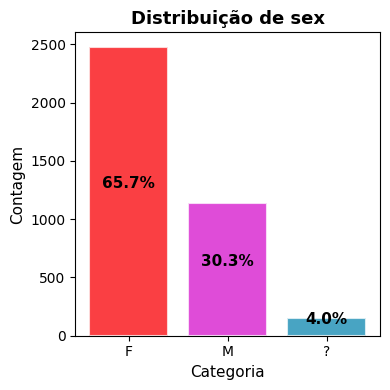

In [31]:
hist_cute(data,'sex')

Para evitar isso, decidiu-se substituir os valores ausentes de maneira aleatória por valor "F" e "M". Como mostra o histograma abaixo, a correção foi realizada com sucesso.

In [32]:
for i in data[data['sex']== '?']['sex'].index:
    # data['sex'].iloc[i] = random.choice(['M', 'F'])
    data.loc[i, "sex"] = random.choice(['M', 'F'])

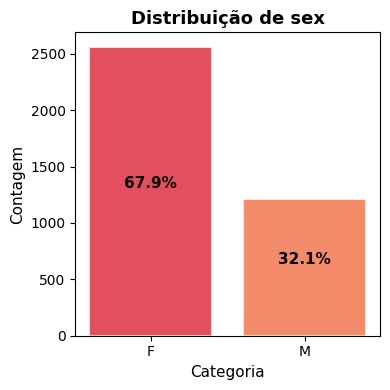

In [33]:
hist_cute(data,'sex')

#### Corrigido os valores ausentes, os valores das variáveis categóricas foram substiuídos com sucesso por seus equivalentes numéricos e boleanos.

In [34]:
for i in column_letters:
        if i == 'sex':
                data[i] = data[i].replace('M', 1)
                data[i] = data[i].replace('F', 0)
        elif i == 'binaryClass':
                data[i] = data[i].replace('P', 1)
                data[i] = data[i].replace('N', 0)
        elif i == 'referral source':
                data[i] = data[i].replace('other', 0)
                data[i] = data[i].replace('STMW', 1)
                data[i] = data[i].replace('SVHC', 2)
                data[i] = data[i].replace('SVHD', 3)
                data[i] = data[i].replace('SVI', 4)
        else:
                data[i] = data[i].replace('t', 1)
                data[i] = data[i].replace('f', 0)
        data[i] = pd.to_numeric(data[i], errors='coerce')
        # print(f'{i}: {data[i].unique()}')

for i in column_letters:
    print(f'{i}: {data[i].unique()}')

sex: [0 1]
on thyroxine: [0 1]
query on thyroxine: [0 1]
on antithyroid medication: [0 1]
sick: [0 1]
pregnant: [0 1]
thyroid surgery: [0 1]
I131 treatment: [0 1]
query hypothyroid: [0 1]
query hyperthyroid: [0 1]
lithium: [0 1]
goitre: [0 1]
tumor: [0 1]
hypopituitary: [0 1]
psych: [0 1]
referral source: [2 0 4 1 3]
binaryClass: [1 0]



#### Finalizada essa etapa, será iniciada a exploração das variáveis e a segunda etapa de tratamento de dados.

## Análise Exploratória

Para criar o modelo é importante compreender as relação de dependências entre as variáveis explicativas ("features") e a variável alvo. Neste projeto, a variável alvo é a 'query hyperthyroid', pois ela indica quais pacientes da base de dados foram diagnosticados como hipertiroidismo (1), e quais não foram. Conforme é possível verificar no histograma abaixo, a variável está bem desbalanceada, com apenas 6,3% dos dados positivos. Essa caracterterística adianta o desafio que será criar esse modelo, especialmente por que o objetivo é minimizar o número de falsos negaticos.


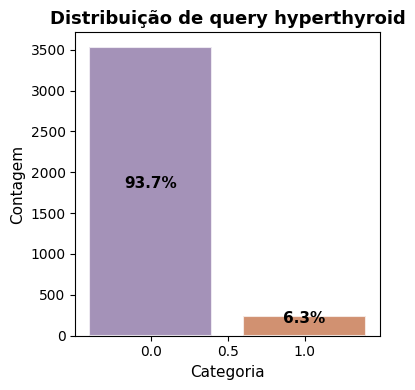

In [35]:
hist_cute(data,'query hyperthyroid')

Tão importante quanto conhecer a distribuição da variável alvo, é conheciar sua relação com as demais variáveis.

#### O mapa de cor a seguir mostra os resultados em ordem decrescento do módulo da correlação.


Com o objetivo de diminuir a complexidade da base, pode-se excluir algumas variáveis com base na sua baixa correlação com a variável alvo. Neste caso, as variáveis com menor correlação e com valores abaixo de 0,01 são:
- 'binaryClass'
- 'FTI' 
- 'hypopituitary'

A variável 'binaryClass' não tem um significado bem claro, sendo, possivelmente, uma variável de controle que não contribuirá para o modelo. Ela será, portanto, removida. Já as outras duas variáveis podem ser relevantes na predição de hipertiroidismo por que carregam informação sobre a condição. O 'FTI' é o 'Free Thyroxine Index', seu valor é uma função do T4 e ele é importante para diferenciar diferentes quadros clínicos, como o 'euthyroid', 'hyperthyroid' e 'hypothyroid'. Já o 'hypopituitary' rara, mas que é importante que seja diferenciada do hipertiroidismo. Por esses motivos, optou-se por não descrtar nenhuma das duas.  

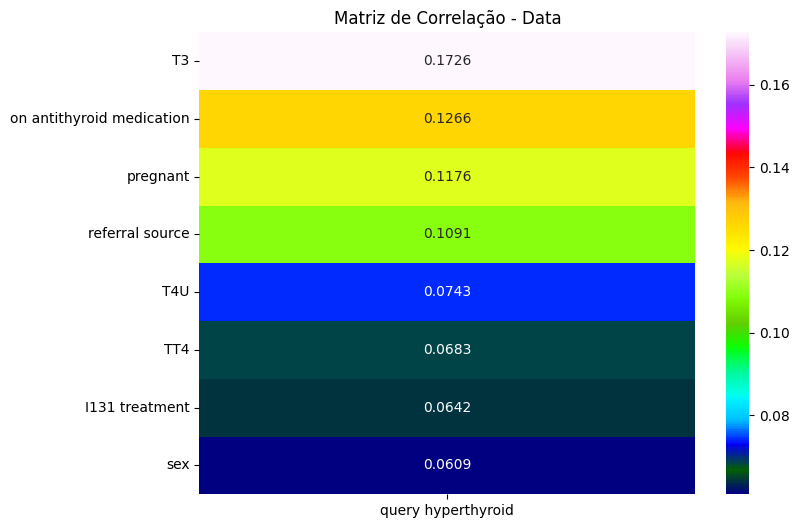

As variáveis que mais influenciam a variável alvo são:

                           query hyperthyroid
T3                                   0.172649
on antithyroid medication            0.126566
pregnant                             0.117605
referral source                      0.109090


As variáveis que menos influenciam a variável alvo são:

                    query hyperthyroid
hypopituitary                 0.004216
query on thyroxine            0.010905
FTI                           0.010947
binaryClass                   0.013446




In [36]:
correlation_matrix = data.select_dtypes(include=['number']).corr()

correlation_matrix_filter = correlation_matrix[correlation_matrix['query hyperthyroid']==1]

plt.figure(figsize=(8, 6))
sns.heatmap(abs(correlation_matrix_filter.T).sort_values(by='query hyperthyroid',ascending=False).iloc[range(1,9)], annot=True, cmap='gist_ncar', fmt=".4f", annot_kws={"size": 10})
plt.title('Matriz de Correlação - Data')
plt.show()

correlation_matrix_t = data_t.select_dtypes(include=['number']).corr()
print('As variáveis que mais influenciam a variável alvo são:\n')
print(f'{abs(correlation_matrix_filter.T).sort_values(by='query hyperthyroid', ascending=False).iloc[[1,2,3,4]]}\n\n')

print('As variáveis que menos influenciam a variável alvo são:\n')
print(f'{abs(correlation_matrix_filter.T).sort_values(by='query hyperthyroid', ascending=True).iloc[[1,2,3,4]]}\n\n')

In [37]:
data.drop('binaryClass',axis=1, inplace=True)
column_letters.remove('binaryClass')


#### Além do balanceamento da variável alvo, é importante analisar a distribuição das demais categorias, mostrada a seguir.

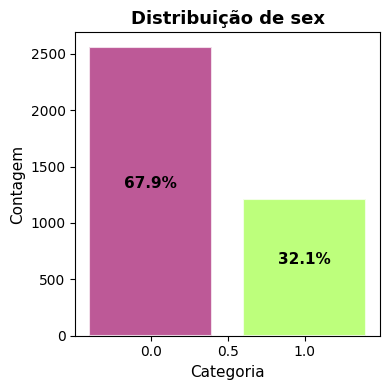

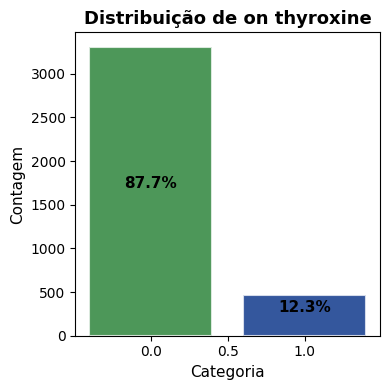

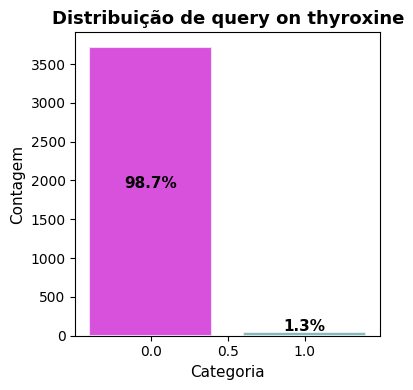

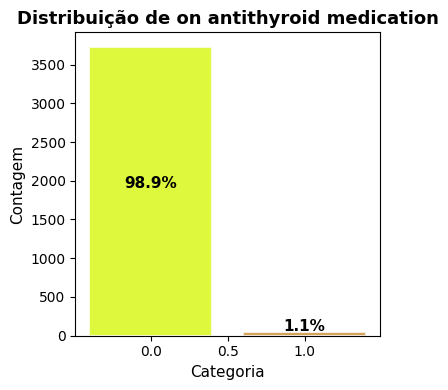

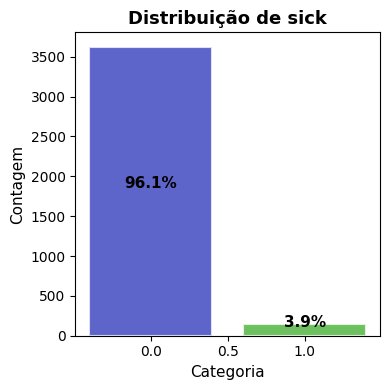

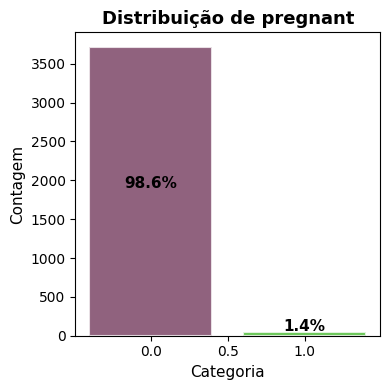

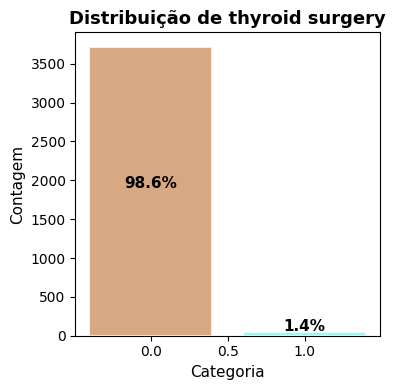

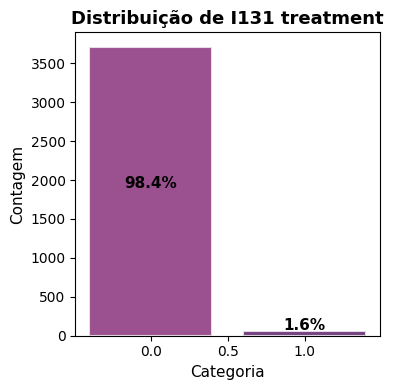

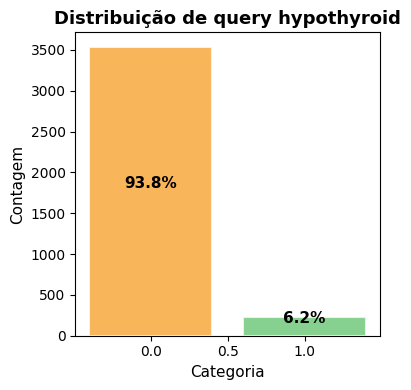

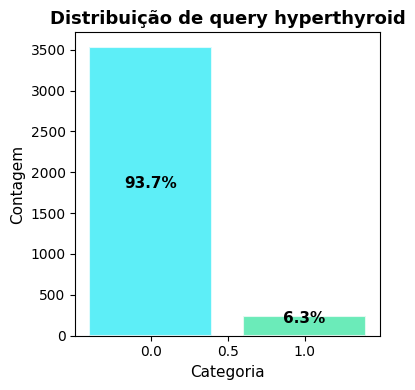

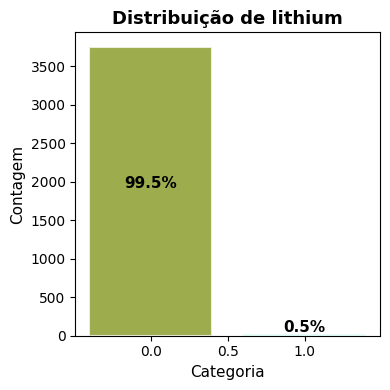

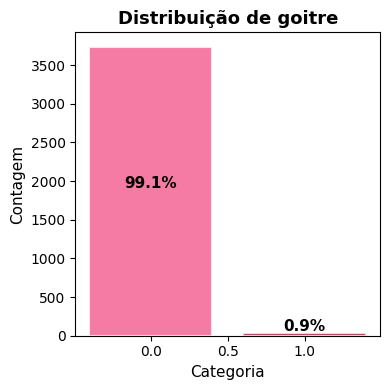

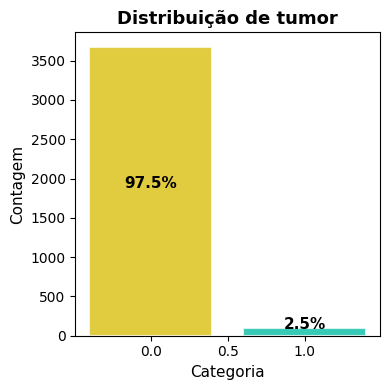

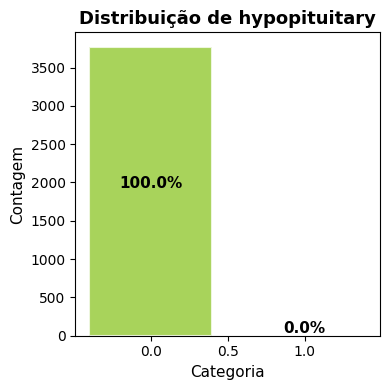

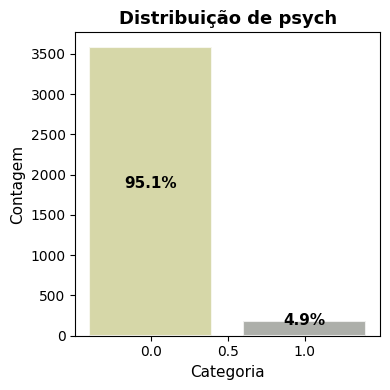

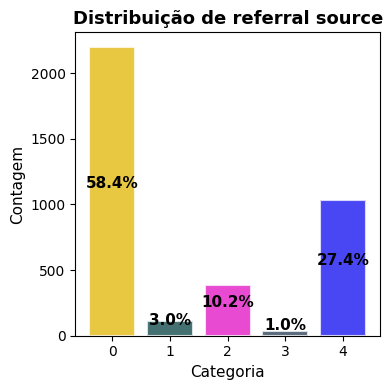

In [38]:
for i in column_letters:
    hist_cute(data,i)

O principal resultado desta análise é que a base é altamente desbalanceada, ou seja, há uma distribuição muito desigual entre os valores da maioria das variáveis categóricas. Dados desbalanceados podem levar o modelo a prever sempre a classe maioritária, prejudicando a previsão da classe minoritária, situação grave para o nosso projeto. Esse comportamento generalizado exige a aplicação de ajustes do balanceamento da base.

Além disso, há uma grande variedade de faixa de valores para cada categoria, de maneira que variáveis numéricas com faixas mais elevadas podem influenciar de maneira desproposcional o modelo. Para isso ela será normalizada. Isso é importante em muitos algoritmos de aprendizagem de máquina para garantir que todas as características sejam tratadas de forma uniforme.

Para o balanceamento, a técnica utilizada será a `SMOTE`. Ela cria exemplos sintéticos da classe minoritária (classe com poucos casos) usando interpolação entre vizinhos mais próximos (`k_neighbors`), equilibrando as classes e melhorando a performance em classificações raras. Ela deve ser aplicada antes das de mais transformações, para garantir que os exemplos criados não serão baseados em dados desescalonados e distorcidos.

A normalização dos dados será feita com a biblioteca `StandardScaler`. Ela padroniza as variáveis explicativas de maneira a ter a média 0 e o desvio de padrão 1. Sem a normalização, features com valores maiores dominam a predição e prejudicam a convergência do modelo durante treinamento. Esse efeito é mais crítico para modelos que são sensíveis à escala de dados, como um dos escolhidos para o projeto, o SVM.    

#### Por motivos que serão discutidos mais para frente do projeto, o `SMOTE` e o `StandardScaler` serão aplicados à base na etapa de treinamento dos modelos.

## Treinamento e Otimização dos Modelos

Terimanada as análises e tratamento, pode-se iniciar a preparação dos dados para o treinamento de máquina, o que pode também ser considerada uma etapa de pré-processamento. Esse tratamento será feito por meio de três estratégias:
- Análise de Componentes Principais (PCA)
- Validação Cruzada
- Integração no pipeline

#### Para poder discutir e aplicar cada uma dessas metodologias, incia-se separando as variáveis explicativas (_features_) da variável alvo (_target_), e suas respectivas separações em bases de treino e teste.

In [39]:
xo = data.drop('query hyperthyroid', axis = 1)
yo = data['query hyperthyroid']

xo_train, xo_test, y_train, y_test = train_test_split(xo, yo, test_size=0.2, random_state=42)

### Análise de Componentes Principais

A Análise de Componentes Principais (PCA) é uma técnica que identifica as principais componentes, variáveis, que influenciam, determinam, o resultado da variável alvo. As componentes são o resultado da combinação linear das variáveis originais que formam as bases ortoganais que descrevem as variáveis explicativas. As principais componentes são aquelas que mais contribuem na formação das variáveis explicativas. Essa metodologia tem como objetivo diminuir a complexidade dos dados, pois diminui o número de campos ao excluir aqueles com menor peso na contribuição.

O gráfico de variância explicada acumulada por componente, a seguir, indica quanto do comportamento da base de dados pode ser explicada a cada novo componente que se adiciona.

In [40]:
pca = PCA(n_components=21)
pca.fit(xo)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()
df_pca = pd.DataFrame({
    'n_components': range(1, len(cumulative_variance) + 1),
    'cumulative_variance': cumulative_variance})

fig = px.line(df_pca, x='n_components', y='cumulative_variance',
    markers=True, title='Variância Explicada Acumulada por Componente',
    labels={'n_components': 'Número de Componentes', 'cumulative_variance': 'Variância Explicada Acumulada'})
fig.update_layout(xaxis=dict(dtick=1, tickmode='linear', range=[1, len(cumulative_variance)]),
                  yaxis=dict(range=[0, 1.1]))
fig.show()


Cada componente indicado no eixo x é uma combinação linear das categorias da base. O gráfico indica que são necessárias apenas 4 componentes para explicar quase completamente aa totalidade dos dados (y ~ 1). Importante destacar que as 4 componentes que descrevem a base são compostas de todas as variáveis da base. Cada uma dessas componentes tem coeficientes que dão um peso de imporância para cada variáve, ou seja, cada coeficiente desses múltiplica uma categoria de análise diferente da base.

A tabela abaixo mostra o coeficiente para cada variável das 4 principais componentes. Repare como nenhuma categoria foi excluída, elas simplesmente foram redistribuídas de uma nova maneira.


In [41]:
componentes = pd.DataFrame(pca.components_, columns=data.columns.drop('query hyperthyroid'))
abs(componentes.loc[[0,1,2,3]])

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral source
0,0.015033,0.001170,0.001930,0.000011,0.000023,0.000130,0.000183,0.000097,0.000027,0.000176,...,0.000067,0.000108,0.000015,0.000161,0.168423,0.006072,0.744920,0.000741,0.645329,0.002987
1,0.969562,0.000748,0.000147,0.000103,0.000388,0.000891,0.000942,0.000191,0.000347,0.000505,...,0.000278,0.000303,0.000021,0.001083,0.048525,0.010685,0.172781,0.002940,0.164413,0.024162
2,0.242970,0.005776,0.000383,0.000057,0.000070,0.000073,0.001251,0.000049,0.000164,0.000434,...,0.000056,0.000557,0.000004,0.000831,0.253553,0.009179,0.642315,0.008326,0.681071,0.007750
3,0.012566,0.000679,0.002663,0.000127,0.000216,0.000509,0.000550,0.000350,0.000050,0.000889,...,0.000275,0.000281,0.000029,0.000317,0.951268,0.008104,0.048138,0.001135,0.304183,0.003153


É comum confundir as componentes com as variáveis de maior correlação, mas é um erro assumir que essas necessariamente tem os maiores coeficientes. Por exemplo, na tabela abaixo estão ordenados os coeficientes, do maior para o menor, da soma das 4 componentes principais. Perceba que nenhuma das categorias mais relacionadas a variável alvo ('T3', 'on antithyroid medication', 'pregnant' e 'referral source') encontram-se no topo da lista com maior módulo do peso total. Isso ocorre porque essa técnica busca a 'correlação' combinada delas, e não isolada. Isso permite que ela diminua a complexidade do modelo sem, com isso, perder a contribuição de variáveis menos impactantes, mas importantes. Esses resultados não invalidam nenhuma das técnicas de análise, pelo contrário, elas se complementam e devem ser usadas cada uma em seu contexto e para sua finalidade.



In [42]:
abs(componentes.iloc[[0,1,2,3]]).sum().sort_values(ascending=False)

FTI                          1.794995
TT4                          1.608155
TSH                          1.421769
age                          1.240131
referral source              0.038051
T3                           0.034040
T4U                          0.013142
sex                          0.008372
on thyroxine                 0.005122
pregnant                     0.002925
psych                        0.002392
query hypothyroid            0.002003
sick                         0.001602
tumor                        0.001250
on antithyroid medication    0.000698
thyroid surgery              0.000686
goitre                       0.000677
I131 treatment               0.000588
query on thyroxine           0.000298
lithium                      0.000286
hypopituitary                0.000069
dtype: float64

#### Por ser uma base com muito componentes (21), para maximizar a descrição do seu comportamento e reduzir a perda de variância, optou-se por selecionar não 4, mas 6 componentes principais.


Na aplicação do PCA, é preciso separar o fit dos dados de treino dos dados de teste para evitar o **vazamento de informação**. Chama-se de vazamento quando, pelo modelo, ou tratamento de dados, ter sido feito com a base completa, seu comportamento final fica prejudicado por conhecer a base de teste. Isso afeta o treinamento do modelo criando tendências e, consequantemente, diminuindo sua performance. Para evitar essa situação, é necessário transforamr as bases de treno e teste separadamente.

In [43]:
pca_n = PCA(n_components=5)
x_train = pca_n.fit_transform(xo_train)
x_test = pca_n.transform(xo_test)

### Validação Cruzada

A Validação Cruzada divide a base de treino em diferendos partes (folds) sem perder a proporção de classes em cada uma delas. Essa metodologia permite que o modelo seja treinado com  distribuições de dados diferentes, otimizando seu resultado. A técnica mais comum, `Kfold`, pode criar conjunto desbalanceados. Como o balanceamento das bases é crítico para os modelos escolhidos, a técnica que será aplicada é a **StratifiedKFold**. Sua vantagem é a garantia de cada parte criada tenha a mesma proporção de classes, ou seja, de que elas serão balanceadas.

### Integração no Pipeline

Há um grave problema quando se aplicam a normaliza dos dados e a validação cruzada no treinamento de um mesmo modelo: durante o calculo dos vizinhos sintéticos, o algorítimo do `SMOTE` "vê" os valores de cada base de teste criada durante a validação cruzada. Em outras palavras, há **vazamento de dados** em todas as "sub" bases de treinamento da validação cruzada. A alternativa mais fácil é a escolha entre a normalização e a cruzada.

Outra alternativa, que permite a aplicação de ambas as técnicas, é a integração em um `pipeline`. A ferramenta `pipeline` permite que os processos sejam aplicados isoladante a cada fold de treinamento. Assim, para cada "sub" base de treino criada, o balanceamento é feito antes da normalização e o treinamento é feito por último. Assim, as "sub" bases de teste da validação cruzada não vazam.

A aplicação será demonstrada mais a frente, após a seleção dos modelos.

### Seleção dos modelos

A principal preocupação deste projeto é **minimizar os falsos negativos**. Em qualquer problema de saúde, minimizar os falsos negativos é crucial, pois significa garantir que os casos reais da doença, no caso, o hipertiroidismo, não sejam perdidos durante a predição. Um falso negativo em um diagnóstico pode levar a complicações sérias, comprometendo a saúde do paciente. O contrário, um falso positivo, é apenas um alarme falso. Portanto, a avaliação dos modelos deve focar em otimizar métricas como o recal e o f1, a prejuízo da precisão e acurácia.

Para embasar a escolha, uma pequena tabela comparativa entre os modelos foi criada, destacando as vantagens que cada um tem para este projeto.

| Modelo                | Vantagens                                                                                     |
|-----------------------|--------------------------------------------------------------------------------------------------|
| **XGBoost**           | Implementa gradiente boosting, conhecido por sua alta precisão em tarefas de classificação. Ele é especialmente eficiente em lidar com dados desbalanceados e **tem opções que minimizam falsos negativos**.        |
| **Random Forest**     | Utiliza várias árvores de decisão para realizar classificações. Por ser um modelo ensemble, o Random Forest é robusto contra o sobreajuste (overfitting) e oferece boa generalização, ajudando **a melhorar a identificação de casos positivos**. |
| **SVM** | Ideal para **problemas de alta dimensionalidade**, o SVM pode lidar com binários e multiclasse de forma eficaz, utilizando diferentes kernels para classificar os dados, o que pode ser benéfico na**minimização de falsos negativos**. |
| **Árvore de Decisão** | São intuitivas e fáceis de interpretar. Elas podem capturar relações não-lineares nos dados, embora sejam propensas a sobreajuste.|
| **Regressão Logística** | É um modelo estatístico utilizado principalmente para problemas binários, mas pode ser estendido para casos multiclasse.|
| **Regressão Polinomial** | Embora usualmente aplicada para regressão, a técnica pode ser adaptada para problemas de classificação. Contudo, a complexidade interpretativa e o risco de sobreajuste requerem atenção cuidadosa. |
| **Naive Bayes**       | É eficiente e rápido, adequado para classificações, especialmente em conjuntos de dados grandes. Embora presuma a independência entre as características, pode ainda fornecer boas estimativas em casos práticos. |
| **K-Means**           | Trata-se de um algoritmo de agrupamento, não especificamente de classificação. Pode ser útil na exploração inicial de dados, mas não deve ser utilizado como modelo de predição direta. |
| **Regressão Linear**  | Este modelo não é apropriado para problemas de classificação, visto que é mais focado em previsões numéricas. Usá-lo para classificação pode resultar em interpretações errôneas. |

A partir desse resumo, fica fácil entender por que os modelos escolhidos foram o **Xboost**, **Random Forest** e **SVM**.

Uma estratégia comumente aplicada para a otimização dos modelos é o **ajuste dos hiperparâmetros**. Isso garante que o modelo não apenas se ajuste bem ao treinamento, mas também seja capaz de generalizar para novos dados.

### Ajuste de Hiperparâmetros

Os hiperparâmetros são "botões" externos ao modelo  que controlam sua complexidade e comportamento, ajustá-los é crucial para melhorar a generalização e, no caso deste projeto, para reduzir falsos negativos. Devido a baixa capacidade computacional, será usado o `RandomizedSearchCV`, pois ela amostra combinações aleatórias de distribuições de parâmetros, explorando mais rapidamente espaços grandes e economizando tempo computacional.

Dentre seus parâmetros, destaca-se o `scoring`, que determina qual será a métrica que determinará a otimização do modelo. Como discutido anteriormente, a métrica de maior importância é o recall, pois ele mede a resposta a seguinte pergunta "De todos os pacientes realmente com hipertiroidismo, quantos foram corretamente identificados?". O parâmetro `class_weight='balanced'` penalizam falsos negativos, o que equilibra o impacto de classes desbalanceadas. Com a mesmo finalidade, o correto ajuste do parâmetro `scale_pos_weight` penaliza falsos negativos, forçando um modelo mais conservador - que prevê mais positivos. 

### Threshold Tuning 

Durante a exploração inicial do treinamento do s modolos, a performance do recall foi muito ruim. Por isso, decidiu-se aplicar mais uma técnica de otimização, o threshold tuning. Essa metodologia busca otimizar o limiar (thereshold) de classificação das classes. O thereshold é o valor de probabilidade que separa as duas classes (suspeita de hipertiroidismo/sem suspeita) em um classificador binário, ou seja, é quem define quando o o valor de probabilidade vai ser interepretado como verdadeiro (1) ou falso (0). Por exemplo, o limiar comumente usado é 0,5, se a propabilidade calculada for maior ou igual a esse valor, a predição é 1, no nosso caso, a predição de que o paciente tem hipertiroidismo. Se o valor for menor do que esse, a predição será 0, a predição de que o paciente não tem hipertiroidismo.

Se o limiar diminuir, por exemplo, para 0,3, mais casos serão classificados como 1. As chances de ser classificado como 1 passarão para 70%, enquanto as chances de ser classificado como 0 passarão para 30%. Essa técnica aumenta os falsos positivos, mas diminui os falsos negativos, ou seja, piora a precisão, mas melhora o recall.

Essa estratégia torna o modelo mais conservador, por isso só é sugerida em casos com bases desbalanceados, especialmente com poucos casos positivos.

A seguir, cada modelo será treinando conforme as metodologias discutidas, o resultado inicial para o limiar padrão será apresentado e brevemente discutido, na sequência o valor de diferentes thresolds serão testados e o melhor será escolhido. Ao final do treinamento dos três modelos, suas performances serão comparadas e discutidas.

## Xboost

In [44]:
xgboost = xgb.XGBClassifier()
# crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=5)
pipeline_xgboost = Pipeline([
    ('scaler', StandardScaler()), # Primeiro normaliza os dados
    ('smote', SMOTE(random_state=42, k_neighbors=5)),   # depois cria exemplos sintéticos
    ('xgboost', xgb.XGBClassifier(random_state=42, scale_pos_weight=2.5))  # scale_pos_weight penaliza falsos negativos
])

param_grid_xgboost = {
    'xgboost__max_depth': [5, 10, 15],              
    'xgboost__n_estimators': [100, 200, 300],
    'xgboost__min_child_weight': [1, 3, 5]
}

xgboost_randomized = RandomizedSearchCV(
    estimator= pipeline_xgboost,
    param_distributions= param_grid_xgboost,
    n_iter=100,  
    random_state=42,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall', 
    n_jobs=-1  )

thresholds_rf = np.arange(0.1, 1.0, 0.05)


In [45]:
xgboost_randomized.fit(x_train, y_train)

best_xgboost = xgboost_randomized.best_estimator_
print("Melhores parâmetros:", xgboost_randomized.best_params_)
print("Melhor score (CV):", xgboost_randomized.best_score_)

# predições no conjunto de teste
y_pred_xgboost = best_xgboost.predict(x_test)

# métricas de avaliação
acc_xgboost = accuracy_score(y_test, y_pred_xgboost)
rec_xgboost = recall_score(y_test, y_pred_xgboost, zero_division=0)
print(f"Acurácia: {acc_xgboost:.4f}")
print(f"Recall: {rec_xgboost:.4f}")
prec_xgboost = precision_score(y_test, y_pred_xgboost, zero_division=0)
f1_xgboost = f1_score(y_test, y_pred_xgboost, zero_division=0)
print(f"Precisão: {prec_xgboost:.4f}")
print(f"F1 score: {f1_xgboost:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_xgboost, zero_division=0))

c:\Users\marina.freitas\AppData\Local\anaconda3\envs\ebac\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning:

The total space of parameters 27 is smaller than n_iter=100. Running 27 iterations. For exhaustive searches, use GridSearchCV.



Melhores parâmetros: {'xgboost__n_estimators': 100, 'xgboost__min_child_weight': 5, 'xgboost__max_depth': 5}
Melhor score (CV): 0.3642375168690958
Acurácia: 0.6967
Recall: 0.4889
Precisão: 0.0965
F1 score: 0.1612
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81       710
           1       0.10      0.49      0.16        45

    accuracy                           0.70       755
   macro avg       0.53      0.60      0.49       755
weighted avg       0.91      0.70      0.78       755



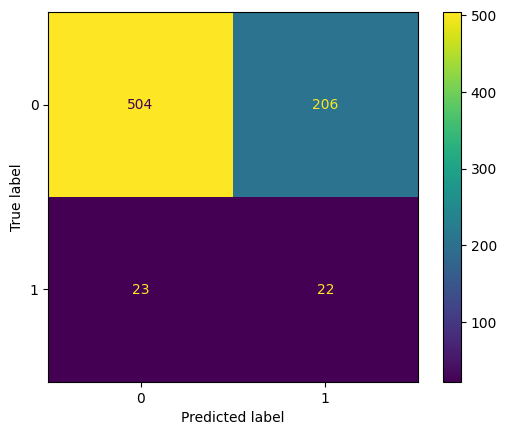

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgboost)

##### Os resultados do treinamento são insatisfatórios. O recall para 1 é de apenas 0,53, e o número de predições positivas verdadeiras é quase igual ao de falsas. Diferentes valores de parâmetros foram testados, mas sem melhora significativa. Para melhorar este cenário, diferentes valores de limiar serão testados, como discutido anteriormente.

In [47]:
print("\n" + "="*80)
print("XGBoost - THRESHOLD TUNING")
print("="*80)

# probabilidades preditas True
y_pred_xgboost_proba = xgboost_randomized.predict_proba(x_test)[:, 1]

thresholds_xgboost = np.arange(0.1, 1.0, 0.05)
results_xgboost = []

for threshold in thresholds_xgboost:
    y_pred_threshold = (y_pred_xgboost_proba >= threshold).astype(int)
    
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred_threshold)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    results_xgboost.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'accuracy': accuracy,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

df_results_xgboost = pd.DataFrame(results_xgboost)
print("Análise de Thresholds:")
print(df_results_xgboost.to_string(index=False))

best_idx_xgboost = df_results_xgboost['recall'].idxmax()
best_threshold_xgboost = df_results_xgboost.loc[best_idx_xgboost, 'threshold']
best_recall_xgboost = df_results_xgboost.loc[best_idx_xgboost, 'recall']
best_precision_xgboost = df_results_xgboost.loc[best_idx_xgboost, 'precision']

print(f"Threshold original (0.5)  → Recall: {rec_xgboost:.4f}, Precisão: {prec_xgboost:.4f}")
print(f"Threshold otimizado ({best_threshold_xgboost:.2f}) → Recall: {best_recall_xgboost:.4f}, Precisão: {best_precision_xgboost:.4f}")
print(f"\nMelhoria de Recall: {(best_recall_xgboost - rec_xgboost)*100:.1f}%")
print(f"Perda de Precisão: {(best_precision_xgboost - prec_xgboost)*100:.1f}%")
print(f"\nVerdadeiros Positivos (casos reais): {df_results_xgboost.loc[best_idx_xgboost, 'TP']:.0f}")
print(f"Falsos Negativos (casos perdidos): {df_results_xgboost.loc[best_idx_xgboost, 'FN']:.0f}")
print(f"Verdadeiros Negativos (casos  reais): {df_results_xgboost.loc[best_idx_xgboost, 'TN']:.0f}")
print(f"Falsos Positivos (alarme falso): {df_results_xgboost.loc[best_idx_xgboost, 'FP']:.0f}")



XGBoost - THRESHOLD TUNING
Análise de Thresholds:
 threshold   recall  precision       f1  accuracy  TP  FP  FN  TN
      0.10 0.733333   0.067210 0.123134  0.377483  33 458  12 252
      0.15 0.733333   0.074157 0.134694  0.438411  33 412  12 298
      0.20 0.688889   0.078880 0.141553  0.501987  31 362  14 348
      0.25 0.644444   0.080332 0.142857  0.539073  29 332  16 378
      0.30 0.600000   0.082067 0.144385  0.576159  27 302  18 408
      0.35 0.577778   0.085809 0.149425  0.607947  26 277  19 433
      0.40 0.577778   0.091228 0.157576  0.631788  26 259  19 451
      0.45 0.555556   0.100402 0.170068  0.676821  25 224  20 486
      0.50 0.488889   0.096491 0.161172  0.696689  22 206  23 504
      0.55 0.488889   0.105263 0.173228  0.721854  22 187  23 523
      0.60 0.444444   0.106952 0.172414  0.745695  20 167  25 543
      0.65 0.377778   0.105590 0.165049  0.772185  17 144  28 566
      0.70 0.355556   0.117647 0.176796  0.802649  16 120  29 590
      0.75 0.288889   0.1

##### A otimização do limiar promoveu uma melhora de 26,7% no recall, alcançando um valor de 0,8, muito superior ao anterior. 9 casos positivos foram erroneamente classificados como negativos, apesar do valor ser muit omenor do que o anterior, ainda é alto, especialmente se lembrarmos que estes números são pessoas.

## Random Forest

In [48]:
rf = RandomForestClassifier(random_state=42)

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),  
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))  # class_weight penaliza falsos negativos
])

param_grid_rf = {
    'rf__max_depth':[None, 10, 20, 30],              
    'rf__n_estimators':range(50, 200),
    'rf__min_samples_split': range(2, 10)
}


rf_Randomized = RandomizedSearchCV(
    estimator= pipeline_rf,
    param_distributions= param_grid_rf,
    n_iter=100,  
    random_state=42,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1  )



In [49]:
rf_Randomized.fit(x_train, y_train)

best_params_rf = rf_Randomized.best_params_
print("Melhores Parâmetros Encontrados:", best_params_rf)

print("Melhor score (CV):", rf_Randomized.best_score_)

# Fazendo previsões no conjunto de teste
y_pred_rf = rf_Randomized.predict(x_test)

# métricas de avaliação
acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
print(f"Acurácia: {acc_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
print(f"Precisão: {prec_rf:.4f}")
print(f"F1 score: {f1_rf:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Melhores Parâmetros Encontrados: {'rf__n_estimators': 169, 'rf__min_samples_split': 9, 'rf__max_depth': 10}
Melhor score (CV): 0.3592442645074224
Acurácia: 0.7603
Recall: 0.4444
Precisão: 0.1136
F1 score: 0.1810
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       710
           1       0.11      0.44      0.18        45

    accuracy                           0.76       755
   macro avg       0.54      0.61      0.52       755
weighted avg       0.91      0.76      0.82       755



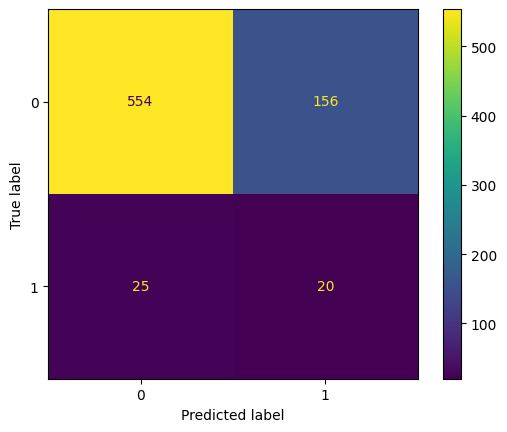

In [50]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)


##### Os resultados do treinamento foram inferiores ao modelo XGBoost. O recall para 1 é de apenas 0,40, gerado por um número de predições verdadeiras positivas inferior ao de falsas. Novamente, o método de threshold tuning será aplicado.

In [52]:
print("\n" + "="*80)
print("RANDOM FOREST - THRESHOLD TUNING")
print("="*80)

# Obter probabilidades preditas (rf com probability=True)
y_pred_rf_proba = rf_Randomized.predict_proba(x_test)[:, 1]

# Testar diferentes thresholds
thresholds_rf = np.arange(0.1, 1.0, 0.05)
results_rf = []

for threshold in thresholds_rf:
    y_pred_threshold = (y_pred_rf_proba >= threshold).astype(int)
    
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred_threshold)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    results_rf.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'accuracy': accuracy,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

df_results_rf = pd.DataFrame(results_rf)
print("\nrf - Análise de Thresholds:")
print(df_results_rf.to_string(index=False))

best_idx_rf = df_results_rf['recall'].idxmax()
best_threshold_rf = df_results_rf.loc[best_idx_rf, 'threshold']
best_recall_rf = df_results_rf.loc[best_idx_rf, 'recall']
best_precision_rf = df_results_rf.loc[best_idx_rf, 'precision']

print('\n')
print(f"Threshold original (0.5)  → Recall: {rec_rf:.4f}, Precisão: {prec_rf:.4f}")
print(f"Threshold otimizado ({best_threshold_rf:.2f}) → Recall: {best_recall_rf:.4f}, Precisão: {best_precision_rf:.4f}")
print(f"\nMelhoria de Recall: {(best_recall_rf - rec_rf)*100:.1f}%")
print(f"Perda de Precisão: {(best_precision_rf - prec_rf)*100:.1f}%")
print(f"\nVerdadeiros Positivos (casos reais): {df_results_rf.loc[best_idx_rf, 'TP']:.0f}")
print(f"Falsos Negativos (casos perdidos): {df_results_rf.loc[best_idx_rf, 'FN']:.0f}")
print(f"Verdadeiros Negativos (casos  reais): {df_results_rf.loc[best_idx_rf, 'TN']:.0f}")
print(f"Falsos Positivos (alarme falso): {df_results_rf.loc[best_idx_rf, 'FP']:.0f}")



RANDOM FOREST - THRESHOLD TUNING

rf - Análise de Thresholds:
 threshold   recall  precision       f1  accuracy  TP  FP  FN  TN
      0.10 0.888889   0.063796 0.119048  0.215894  40 587   5 123
      0.15 0.800000   0.063717 0.118033  0.287417  36 529   9 181
      0.20 0.777778   0.071283 0.130597  0.382781  35 456  10 254
      0.25 0.711111   0.073733 0.133612  0.450331  32 402  13 308
      0.30 0.711111   0.081633 0.146453  0.505960  32 360  13 350
      0.35 0.666667   0.089286 0.157480  0.574834  30 306  15 404
      0.40 0.622222   0.101449 0.174455  0.649007  28 248  17 462
      0.45 0.555556   0.113636 0.188679  0.715232  25 195  20 515
      0.50 0.444444   0.113636 0.180995  0.760265  20 156  25 554
      0.55 0.311111   0.112903 0.165680  0.813245  14 110  31 600
      0.60 0.200000   0.104651 0.137405  0.850331   9  77  36 633
      0.65 0.177778   0.140351 0.156863  0.886093   8  49  37 661
      0.70 0.111111   0.161290 0.131579  0.912583   5  26  40 684
      0.75 0.

##### A otimização do limiar promoveu uma melhora de 48,9% no recall, alcançando um valor de aproximadamente 0,9, muito superior ao anterior em ambos os modelos, mesmo o XGBoost tunado. 5 casos positivos foram erroneamente classificados como negativos, um resultado 50% melhor do que o do modelo anterior.

## SVM

In [53]:
svm = SVC(random_state = 1, C = 1.0)

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),  
    ('svm', SVC(random_state=1, C=1.0, class_weight='balanced', probability=True)) 
])

param_grid_svm = {
    'svm__C': [1, 10, 100],
    'svm__kernel': ['rbf', 'poly']
}

svm_randomized = RandomizedSearchCV(
    estimator= pipeline_svm,
    param_distributions= param_grid_svm,
    verbose=2,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall', 
    n_jobs=-1  )

In [54]:
svm_randomized.fit(x_train, y_train)
print("Melhores Parâmetros Encontrados:", svm_randomized.best_params_)
print("Melhor score (CV):", svm_randomized.best_score_)
print("Melhor Estimator:",svm_randomized.best_estimator_ )
y_pred_svm = svm_randomized.predict(x_test)

# métricas de avaliação
acc_svm = accuracy_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
print(f"Acurácia: {acc_svm:.4f}")
print(f"Recall: {rec_svm:.4f}")
prec_svm= precision_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)
print(f"Precisão: {prec_svm:.4f}")
print(f"F1 score: {f1_svm:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

c:\Users\marina.freitas\AppData\Local\anaconda3\envs\ebac\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning:

The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.



Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores Parâmetros Encontrados: {'svm__kernel': 'poly', 'svm__C': 1}
Melhor score (CV): 0.8233468286099865
Melhor Estimator: Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('svm',
                 SVC(C=1, class_weight='balanced', kernel='poly',
                     probability=True, random_state=1))])
Acurácia: 0.3417
Recall: 0.8444
Precisão: 0.0720
F1 score: 0.1326
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.31      0.47       710
           1       0.07      0.84      0.13        45

    accuracy                           0.34       755
   macro avg       0.52      0.58      0.30       755
weighted avg       0.92      0.34      0.45       755



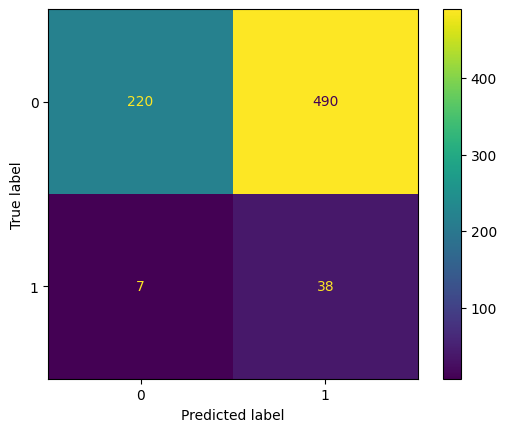

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)

##### Os resultados do modelo SVM, que é mais robusto, foi superior aos anteriores, se aproximando do Random Forest tunado. Com a esperança de obter um resultado ainda melhor, o método de threshold tuning também será aplicado a ele.

In [56]:
print("\n" + "="*80)
print("SVM - THRESHOLD TUNING")
print("="*80)

# Obter probabilidades preditas (SVM com probability=True)
y_pred_svm_proba = svm_randomized.predict_proba(x_test)[:, 1]

# Testar diferentes thresholds
thresholds_svm = np.arange(0.1, 1.0, 0.05)
results_svm = []

for threshold in thresholds_svm:
    y_pred_threshold = (y_pred_svm_proba >= threshold).astype(int)
    
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred_threshold)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    results_svm.append({
        'threshold': threshold, 'recall': recall, 'precision': precision,
        'f1': f1, 'accuracy': accuracy, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn })

df_results_svm = pd.DataFrame(results_svm)
print("\nSVM - Análise de Thresholds:")
print(df_results_svm.to_string(index=False))

best_idx_svm = df_results_svm['recall'].idxmax()
best_threshold_svm = df_results_svm.loc[best_idx_svm, 'threshold']
best_recall_svm = df_results_svm.loc[best_idx_svm, 'recall']
best_precision_svm = df_results_svm.loc[best_idx_svm, 'precision']

print(f"Threshold original (0.5)  → Recall: {rec_svm:.4f}, Precisão: {prec_svm:.4f}")
print(f"Threshold otimizado ({best_threshold_svm:.2f}) → Recall: {best_recall_svm:.4f}, Precisão: {best_precision_svm:.4f}")
print(f"\nMelhoria de Recall: {(best_recall_svm - rec_svm)*100:.1f}%")
print(f"Perda de Precisão: {(best_precision_svm - prec_svm)*100:.1f}%")
print(f"\nVerdadeiros Positivos (casos reais): {df_results_svm.loc[best_idx_svm, 'TP']:.0f}")
print(f"Falsos Negativos (casos perdidos): {df_results_svm.loc[best_idx_svm, 'FN']:.0f}")
print(f"Verdadeiros Negativos (casos  reais): {df_results_svm.loc[best_idx_svm, 'TN']:.0f}")
print(f"Falsos Positivos (alarme falso): {df_results_svm.loc[best_idx_svm, 'FP']:.0f}")



SVM - THRESHOLD TUNING

SVM - Análise de Thresholds:
 threshold   recall  precision       f1  accuracy  TP  FP  FN  TN
      0.10 0.955556   0.058904 0.110968  0.087417  43 687   2  23
      0.15 0.933333   0.058659 0.110381  0.103311  42 674   3  36
      0.20 0.911111   0.060117 0.112792  0.145695  41 641   4  69
      0.25 0.888889   0.061920 0.115774  0.190728  40 606   5 104
      0.30 0.888889   0.067682 0.125786  0.263576  40 551   5 159
      0.35 0.888889   0.070547 0.130719  0.295364  40 527   5 183
      0.40 0.866667   0.071691 0.132428  0.323179  39 505   6 205
      0.45 0.844444   0.073501 0.135231  0.356291  38 479   7 231
      0.50 0.755556   0.077449 0.140496  0.449007  34 405  11 305
      0.55 0.555556   0.096525 0.164474  0.663576  25 234  20 476
      0.60 0.200000   0.109756 0.141732  0.855629   9  73  36 637
      0.65 0.088889   0.160000 0.114286  0.917881   4  21  41 689
      0.70 0.088889   0.250000 0.131148  0.929801   4  12  41 698
      0.75 0.044444   

##### A otimização do limiar promoveu uma melhora de apenas 11,1% no recall, mas como seu resultado já era superior, seu recall alcançando um valor de aproximadamente 0,96, muito superior a todos os modelos anteriores. Apenas 2 casos positivos foram erroneamente classificados como negativos, ainda que o ideal fosse que nenhum caso fosse perdido, esse resultado é muito bom.

## Conclusão

In [57]:
print("\n" + "="*20," COMPARAÇÃO DOS MODELOS OTIMIZADOS ", "="*20)
summary_data = {
    'Modelo': ['XGBoost', 'Random Forest', 'SVM'],
    'Threshold': [f"{best_threshold_xgboost:.2f}", f"{best_threshold_rf:.2f}", f"{best_threshold_svm:.2f}"],
    'Recall': [f"{best_recall_xgboost:.4f}", f"{best_recall_rf:.4f}", f"{best_recall_svm:.4f}"],
    'Precisão': [f"{best_precision_xgboost:.4f}", f"{best_precision_rf:.4f}", f"{best_precision_svm:.4f}"],
}

df_summary = pd.DataFrame(summary_data)
print("\n" + df_summary.to_string(index=False))
recalls_otimizados = [best_recall_xgboost, best_recall_rf, best_recall_svm]
best_model_idx = recalls_otimizados.index(max(recalls_otimizados))
models = ['XGBoost', 'Random Forest', 'SVM']
print(f"\n{'='*20} MELHOR MODELO: {models[best_model_idx].upper()}{'='*20} ")

if best_model_idx == 0:
    print(f"Threshold recomendado: {best_threshold_xgboost:.2f}\nRecall: {best_recall_xgboost:.4f}", f"Precisão: {best_precision_xgboost:.4f}\nVerdadeiros Positivos (casos reais): {df_results_svm.loc[best_idx_svm, 'TP']:.0f}", f"Falsos Negativos (casos perdidos): {df_results_svm.loc[best_idx_svm, 'FN']:.0f}", f"Verdadeiros Negativos (casos  reais): {df_results_svm.loc[best_idx_svm, 'TN']:.0f}", f"Falsos Positivos (alarme falso): {df_results_svm.loc[best_idx_svm, 'FP']:.0f}")
elif best_model_idx == 1:
    print(f"Threshold recomendado: {best_threshold_rf:.2f}", f"\nRecall: {best_recall_rf:.4f}", f"\nPrecisão: {best_precision_rf:.4f}", f"\n\nVerdadeiros Positivos (casos reais): {df_results_svm.loc[best_idx_svm, 'TP']:.0f}", f"\nFalsos Negativos (casos perdidos): {df_results_svm.loc[best_idx_svm, 'FN']:.0f}", f"\nVerdadeiros Negativos (casos  reais): {df_results_svm.loc[best_idx_svm, 'TN']:.0f}", f"\nFalsos Positivos (alarme falso): {df_results_svm.loc[best_idx_svm, 'FP']:.0f}")
else:
    print(f"Threshold recomendado: {best_threshold_svm:.2f}",f"\nRecall: {best_recall_svm:.4f}",f"\nPrecisão: {best_precision_svm:.4f}",f"\n\nVerdadeiros Positivos (casos reais): {df_results_svm.loc[best_idx_svm, 'TP']:.0f}",f"\nFalsos Negativos (casos perdidos): {df_results_svm.loc[best_idx_svm, 'FN']:.0f}",f"\nVerdadeiros Negativos (casos  reais): {df_results_svm.loc[best_idx_svm, 'TN']:.0f}",f"\nFalsos Positivos (alarme falso): {df_results_svm.loc[best_idx_svm, 'FP']:.0f}")



====================  COMPARAÇÃO DOS MODELOS OTIMIZADOS  ====================

       Modelo Threshold Recall Precisão
      XGBoost      0.10 0.7333   0.0672
Random Forest      0.10 0.8889   0.0638
          SVM      0.10 0.9556   0.0589

==================== MELHOR MODELO: SVM==================== 
Threshold recomendado: 0.10 
Recall: 0.9556 
Precisão: 0.0589 

Verdadeiros Positivos (casos reais): 43 
Falsos Negativos (casos perdidos): 2 
Verdadeiros Negativos (casos  reais): 23 
Falsos Positivos (alarme falso): 687


Em todos os modelos, o limiar otimizado é igual a 0,1. Isso significa que apenas probabilidades menores do que 10% serão classificadas como negativas, ou seja, se o paciente apresentar uma probabilidade superior a 10% de ter hipertiroidismo, ele será apto para uma investigação sobre hipertiroidismo.

Um recall de 0,96 é ótimo, pois foram apenas 2 casos perdidos. Contudo, 688 alarmes falsos foram criados, o que representa quase a totalidade da base de dados! Por essa perspectiva, nenhum dos modelos foi satisfatório. Considerando a importância da redução do recall, não é aceitável buscar um recall baixo para alcançar uma precisão mais alta.

Por esse motivo, ao longo do desenvolvimento do projeto, outras estratégias foram testadas. Dentre elas, as categorias com menor correlação foram excluídas, diferentes números de componentes principais foram testadas, entre outras variações nos hiperparâmetros e pré-processamento dos dados. Sendo assim, apesar de dar como encerrado o projeto, não considero que o modelo desenvolvido é uma solução viável para o problema proposto. 

